<a href="https://www.kaggle.com/code/gonnzaga/victorgonzaga-dataset-irisspecies?scriptVersionId=348666722" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Classificação do Dataset Iris com SVM (Support Vector Machine)

Nesta atividade eu reavaliei o dataset Iris usando os dados obtidos diretamente do Kaggle, fazendo a Análise Exploratória de Dados (EDA) e desenvolvendo um modelo de classificação usando **exclusivamente o algoritmo SVM**.

**Dataset utilizado:** [Iris Species](https://www.kaggle.com/datasets/menegidio/iris-species) — eu criei este notebook diretamente a partir da página do dataset no Kaggle.

## 1. Setup

Primeiro eu importei todas as bibliotecas que ia precisar ao longo do notebook:

- **pandas**: uso para carregar o CSV e manipular os dados em formato de tabela (DataFrame).
- **numpy**: uso para alguns cálculos numéricos, como tirar médias de resultados.
- **matplotlib**: é a base para os gráficos.
- **seaborn**: construído em cima do matplotlib, uso para deixar os gráficos da EDA mais completos e informativos, com menos código.
- **train_test_split**: para dividir os dados entre treino e teste.
- **cross_val_score**: para fazer uma validação cruzada e confirmar se o resultado do modelo é consistente.
- **SVC** (*Support Vector Classifier*): é a implementação do SVM para classificação — o único algoritmo que eu usei nesta atividade, como pedido.
- **StandardScaler**: para normalizar as variáveis numéricas, uma etapa que vou explicar melhor no passo 6.
- **accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay**: as métricas que usei para avaliar o modelo no final.

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


## 2. Load Dataset (Carregando o Dataset)

Como criei este notebook diretamente a partir da página do dataset no Kaggle, o arquivo `Iris.csv` já veio anexado automaticamente ao ambiente, dentro da pasta `/kaggle/input/`. Por isso, em nenhum momento uso o `load_iris()` do scikit-learn: os dados usados aqui são o CSV real, disponibilizado no dataset da atividade.

Antes de carregar, conferi qual era o caminho exato do arquivo dentro de `/kaggle/input/`, olhando o painel de *Input* do notebook, e usei esse caminho diretamente na chamada do `pd.read_csv()` abaixo.

In [2]:
# Lê o arquivo CSV do dataset "Iris Species" diretamente do caminho onde o Kaggle
# anexou o dataset a este notebook, e guarda o conteúdo em um DataFrame (tabela) chamado df.
df = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")

# .head() mostra só as 5 primeiras linhas da tabela, só para conferir rapidamente
# se o carregamento deu certo e se as colunas fazem sentido (Id, medidas, Species).
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


A tabela acima mostrou as colunas `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm` e `Species`, então confirmei que o carregamento funcionou e que os dados são realmente os do dataset anexado.

## 3. Initial Inspection (Inspeção Inicial / Análise Exploratória de Dados)

Nesta etapa eu fiz a Análise Exploratória de Dados pedida na atividade. Antes de treinar qualquer modelo, achei importante entender bem os dados, então organizei minha análise em 7 partes:

1. Estrutura geral do dataset
2. Estatísticas descritivas
3. Qualidade dos dados (valores ausentes e duplicados)
4. Balanceamento das classes
5. Distribuição de cada medida
6. Relação entre as variáveis (pairplot)
7. Correlação entre as medidas

### 3.1 Estrutura geral do dataset

In [3]:
# .info() mostra o tipo de cada coluna e quantos valores não nulos existem em cada uma
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Com isso eu vi que o dataset tem 150 linhas (150 flores) e 6 colunas: `Id` (que não usei na modelagem, porque é só um identificador), as 4 medidas numéricas e `Species`, que é a variável que eu quero prever.

### 3.2 Estatísticas descritivas

In [4]:
# .describe() me trouxe média, desvio padrão, mínimo, máximo e quartis de cada medida numérica
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Aqui eu percebi que as 4 medidas têm escalas bem diferentes entre si — por exemplo, `SepalLengthCm` varia bem mais em valor absoluto do que `PetalWidthCm`. Guardei essa observação porque ela justifica a normalização que eu faço mais para frente, no passo 6.

### 3.3 Qualidade dos dados: valores ausentes e duplicados

In [5]:
# Verifiquei se havia algum valor ausente em cada coluna
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# Verifiquei também se havia linhas duplicadas
print("\nQuantidade de linhas duplicadas:", df.duplicated().sum())


Valores ausentes por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Quantidade de linhas duplicadas: 0


Não encontrei nenhum valor ausente nem nenhuma linha duplicada, então segui direto para a análise sem precisar tratar nada nesse sentido.

### 3.4 Balanceamento das classes (espécies)

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


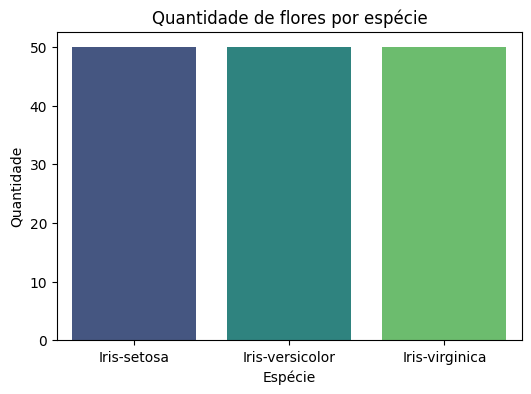

In [6]:
print(df["Species"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Species", hue="Species", palette="viridis", legend=False)
plt.title("Quantidade de flores por espécie")
plt.xlabel("Espécie")
plt.ylabel("Quantidade")
plt.show()


Achei importante checar isso porque, se uma espécie tivesse muito mais exemplos do que as outras, a acurácia sozinha poderia me enganar mais na frente. Mas confirmei que o dataset é perfeitamente balanceado: 50 flores de cada uma das 3 espécies. Isso me deu confiança para usar a acurácia como uma das métricas de avaliação do modelo.

### 3.5 Distribuição de cada medida, por espécie

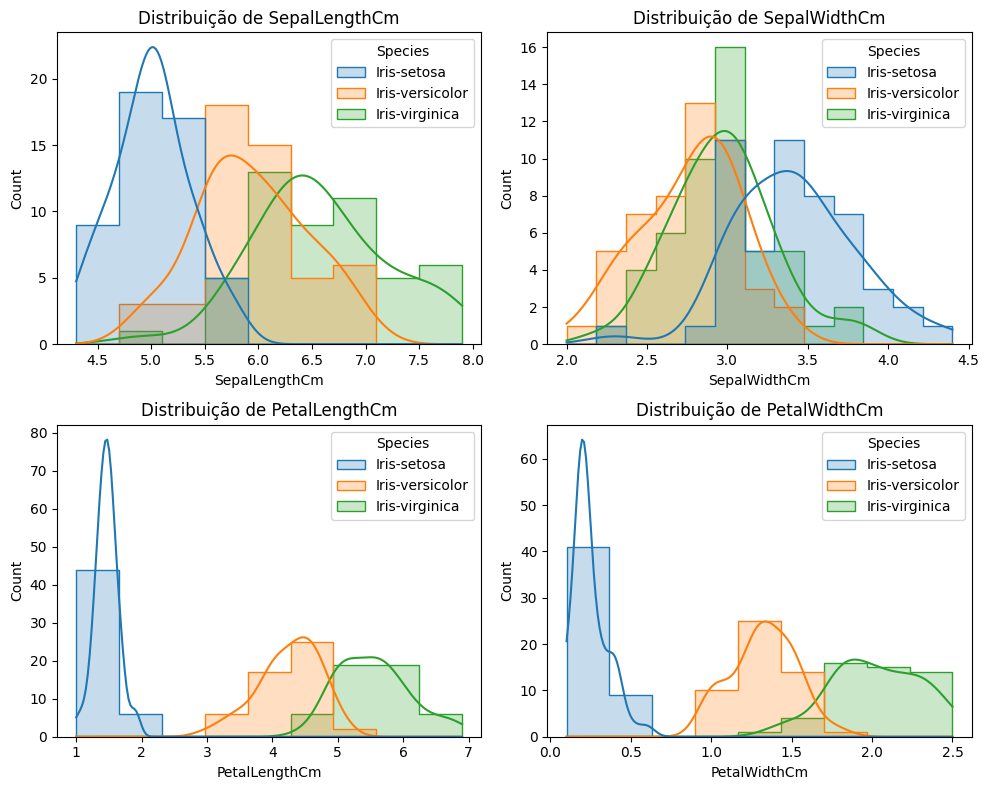

In [7]:
colunas_numericas = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

fig, eixos = plt.subplots(2, 2, figsize=(10, 8))
eixos = eixos.flatten()

for i, coluna in enumerate(colunas_numericas):
    sns.histplot(data=df, x=coluna, hue="Species", kde=True, ax=eixos[i], element="step")
    eixos[i].set_title(f"Distribuição de {coluna}")

plt.tight_layout()
plt.show()


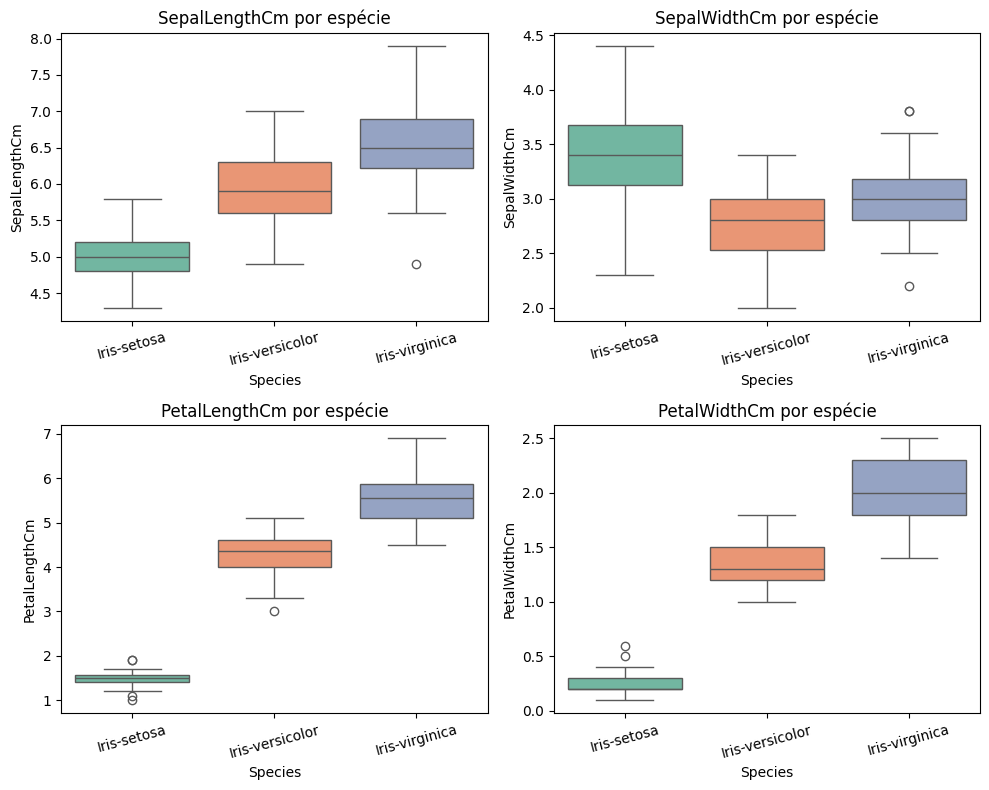

In [8]:
fig, eixos = plt.subplots(2, 2, figsize=(10, 8))
eixos = eixos.flatten()

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(data=df, x="Species", y=coluna, hue="Species", palette="Set2", legend=False, ax=eixos[i])
    eixos[i].set_title(f"{coluna} por espécie")
    eixos[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Esses gráficos foram, na minha opinião, a parte mais reveladora da EDA. Olhando para os histogramas e boxplots, principalmente das medidas de **pétala** (`PetalLengthCm` e `PetalWidthCm`), eu vi que a espécie *Iris-setosa* fica completamente separada das outras duas — os valores dela nem chegam a se sobrepor. Já *Iris-versicolor* e *Iris-virginica* se sobrepõem um pouco entre si.

Com base nisso, eu já formei uma expectativa antes mesmo de treinar o modelo: esperava que ele acertasse 100% das *setosa*, e que qualquer erro que aparecesse estivesse concentrado entre *versicolor* e *virginica*.

### 3.6 Relação entre pares de variáveis

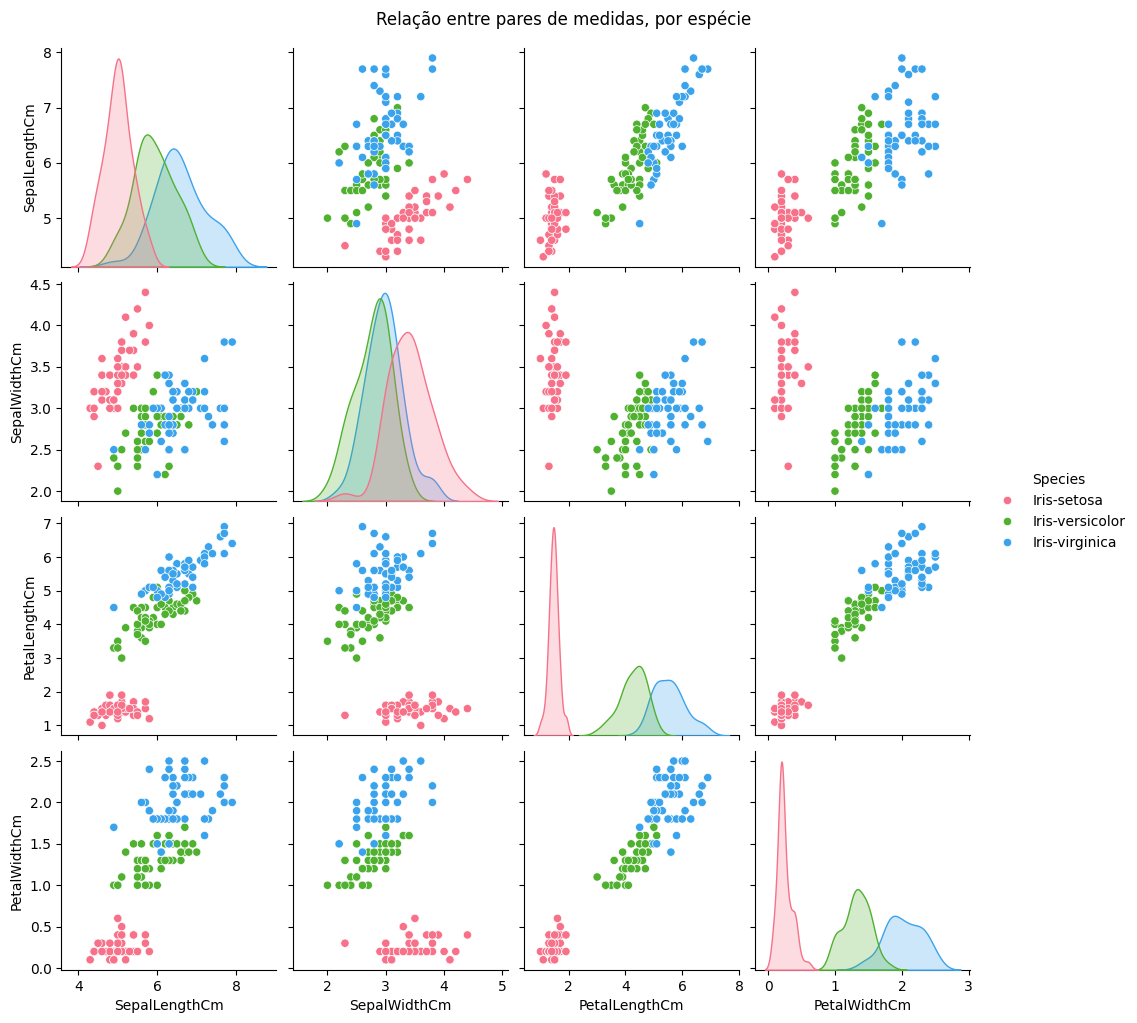

In [9]:
sns.pairplot(df.drop(columns=["Id"]), hue="Species", palette="husl")
plt.suptitle("Relação entre pares de medidas, por espécie", y=1.02)
plt.show()


Esse pairplot confirmou o que eu já tinha visto nos boxplots: existe um espaço vazio nítido separando *setosa* das outras duas espécies, em praticamente todos os pares de medidas. Isso me indicou que o problema é, em boa parte, linearmente separável para essa espécie, mas não totalmente linear entre *versicolor* e *virginica* — e foi essa observação que me guiou na escolha do kernel do SVM, que explico no passo 7.

### 3.7 Correlação entre as medidas

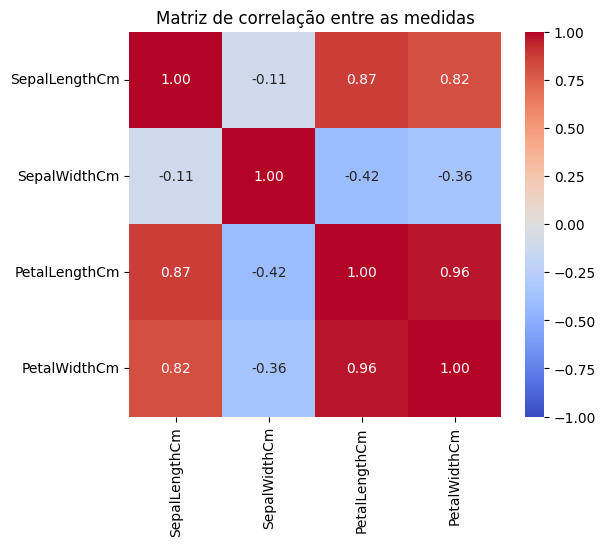

In [10]:
matriz_correlacao = df[colunas_numericas].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlação entre as medidas")
plt.show()


Por fim, olhei a correlação entre as medidas e encontrei uma correlação bem alta entre `PetalLengthCm` e `PetalWidthCm` — o que faz sentido, já que pétalas mais compridas tendem a ser também mais largas. Decidi manter as 4 medidas no modelo mesmo assim, porque o SVM não exige a remoção de variáveis correlacionadas.

## 4. Data Preparation (Preparação dos Dados)

Depois de entender bem os dados, parti para a preparação. Fiz duas coisas aqui:

1. Removi a coluna `Id`, porque ela é só um número sequencial de identificação, sem nenhuma relação real com a espécie da flor.
2. Separei o que é entrada do modelo (as 4 medidas, que chamo de `X`) do que é a saída que eu quero prever (a espécie, que chamo de `y`).

In [11]:
# Removo a coluna Id, se ela ainda existir
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

# X: minhas features (entradas) -> todas as colunas, menos "Species"
X = df.drop(columns=["Species"])

# y: meu target (saída) -> a espécie que eu quero prever
y = df["Species"]

print("Formato de X (features):", X.shape)
print("Formato de y (target):", y.shape)
X.head()


Formato de X (features): (150, 4)
Formato de y (target): (150,)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 5. Train/Test Split (Divisão em Treino e Teste)

Eu não quis treinar o modelo e testar nos mesmos dados, porque isso não mostraria se ele realmente aprendeu ou só "decorou" as respostas. Por isso, separei uma parte dos dados para o modelo aprender (treino) e guardei uma parte que ele nunca vê durante o treinamento, só para medir o desempenho de verdade (teste).

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # separei 20% dos dados para teste e 80% para treino
    random_state=42,    # fixei esse valor para a divisão ser sempre a mesma, deixando o notebook reprodutível
    stratify=y           # pedi para manter a proporção das 3 espécies igual no treino e no teste
)

print("Tamanho do conjunto de treino:", X_train.shape[0], "amostras")
print("Tamanho do conjunto de teste:", X_test.shape[0], "amostras")

print("\nProporção de espécies no treino:")
print(y_train.value_counts(normalize=True))

print("\nProporção de espécies no teste:")
print(y_test.value_counts(normalize=True))


Tamanho do conjunto de treino: 120 amostras
Tamanho do conjunto de teste: 30 amostras

Proporção de espécies no treino:
Species
Iris-setosa        0.333333
Iris-virginica     0.333333
Iris-versicolor    0.333333
Name: proportion, dtype: float64

Proporção de espécies no teste:
Species
Iris-setosa        0.333333
Iris-virginica     0.333333
Iris-versicolor    0.333333
Name: proportion, dtype: float64


Conferi que as proporções de cada espécie ficaram bem parecidas no treino e no teste — foi exatamente por isso que usei o `stratify=y`.

## 6. Normalization (Normalização)

Como eu tinha percebido lá no passo 3.2, as 4 medidas têm escalas diferentes entre si. Isso importa bastante para o SVM, porque ele se baseia em distâncias entre os pontos no espaço das features para encontrar a fronteira de separação entre as classes. Se eu deixasse uma medida com números muito maiores que as outras, ela acabaria "dominando" o cálculo de distância, mesmo sem ser mais importante de verdade para diferenciar as espécies.

Para resolver isso, usei o `StandardScaler`, que transforma cada coluna para ter média 0 e desvio padrão 1, aplicando a fórmula:

$$z = \frac{x - \mu}{\sigma}$$

Um cuidado que tomei: eu ajustei (`fit`) o `scaler` usando **apenas** os dados de treino, e só apliquei (`transform`) essa mesma transformação no teste. Fiz assim de propósito para não deixar informação do conjunto de teste "vazar" para o treinamento — se eu tivesse calculado a normalização usando também o teste, a minha avaliação final ficaria otimista demais e não seria confiável.

In [13]:
scaler = StandardScaler()

# Ajusto o scaler com o treino e já aplico a transformação nele
X_train_norm = scaler.fit_transform(X_train)

# Aplico no teste a MESMA transformação aprendida no treino, sem recalcular nada
X_test_norm = scaler.transform(X_test)

# Confirmo que, após a normalização, a média de cada coluna do treino ficou próxima de 0
print("Médias após normalização (treino):", np.round(X_train_norm.mean(axis=0), 4))
print("Desvios padrão após normalização (treino):", np.round(X_train_norm.std(axis=0), 4))


Médias após normalização (treino): [-0.  0. -0.  0.]
Desvios padrão após normalização (treino): [1. 1. 1. 1.]


## 7. Train SVM Model (Treinando o Modelo SVM)

Aqui eu treinei o modelo usando exclusivamente SVM, através da classe `SVC` do scikit-learn, como pedido na atividade.

Para explicar rapidamente como o SVM funciona: a ideia dele é encontrar a fronteira de decisão que separa as classes com a **maior margem possível** — ou seja, ele tenta deixar a maior distância possível entre a fronteira e os pontos mais próximos de cada classe. Esses pontos mais próximos, que "sustentam" essa margem, são chamados de vetores de suporte, e é daí que vem o nome do algoritmo.

Os parâmetros que escolhi:
- **kernel="rbf"**: optei por esse kernel porque, na minha EDA (passo 3.6), eu vi que *Iris-versicolor* e *Iris-virginica* não são perfeitamente separáveis por uma linha reta. O kernel RBF permite fronteiras curvas, então ele consegue capturar melhor essa relação não-linear entre essas duas espécies.
- **C=1.0**: usei o valor padrão, que equilibra bem "acertar o treino" com "generalizar para dados novos", sem deixar o modelo decorar demais os dados de treino.
- **gamma="scale"**: deixei o scikit-learn calcular esse valor automaticamente com base na variância dos meus dados, o que costuma funcionar bem como ponto de partida.

In [14]:
modelo_svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

# Treino o modelo com os dados de treino já normalizados
modelo_svm.fit(X_train_norm, y_train)

print("Modelo treinado!")
print("Quantidade de vetores de suporte por classe:", modelo_svm.n_support_)


Modelo treinado!
Quantidade de vetores de suporte por classe: [10 18 19]


A saída `n_support_` me mostrou quantos pontos de cada classe viraram vetores de suporte, ou seja, quantos pontos realmente influenciaram onde a fronteira de decisão foi desenhada.

## 8. Prediction (Fazendo Previsões)

Com o modelo treinado, usei ele para prever as espécies das flores do conjunto de teste — lembrando que essas flores não foram usadas em nenhum momento durante o treinamento.

In [15]:
y_pred = modelo_svm.predict(X_test_norm)

# Comparei lado a lado a resposta real com a previsão do modelo, para as 10 primeiras amostras de teste
pd.DataFrame({
    "Real": y_test.values,
    "Previsto": y_pred,
    "Acertou?": y_test.values == y_pred
}).head(10)


,Real,Previsto,Acertou?
0,Iris-setosa,Iris-setosa,True
1,Iris-virginica,Iris-virginica,True
2,Iris-versicolor,Iris-versicolor,True
3,Iris-versicolor,Iris-versicolor,True
4,Iris-setosa,Iris-setosa,True
5,Iris-versicolor,Iris-versicolor,True
6,Iris-setosa,Iris-setosa,True
7,Iris-setosa,Iris-setosa,True
8,Iris-virginica,Iris-virginica,True
9,Iris-versicolor,Iris-versicolor,True


## 9. Evaluation (Avaliação dos Resultados)

Para avaliar o modelo, usei quatro métricas clássicas:

1. Acurácia
2. Classification report (por espécie)
3. Matriz de confusão
4. Validação cruzada, para confirmar que o resultado é consistente

### 9.1 Acurácia

In [16]:
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acuracia:.4f} ({acuracia * 100:.2f}%)")


Acurácia no conjunto de teste: 0.9667 (96.67%)


A acurácia me deu uma visão geral, mas eu sei que ela sozinha pode esconder detalhes — por isso complementei com as métricas por espécie a seguir.

### 9.2 Classification Report (métricas por espécie)

In [17]:
print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



Nesse relatório, para cada espécie eu tenho:

- **precision**: das vezes que o modelo previu essa espécie, quantas realmente eram dela.
- **recall**: das flores que realmente são dessa espécie, quantas o modelo conseguiu identificar.
- **f1-score**: uma média entre precision e recall.
- **support**: quantos exemplos daquela espécie existem no meu conjunto de teste.

Como eu já esperava pela EDA, a *Iris-setosa* ficou com precision e recall de 100%. Se apareceu algum erro no meu resultado, ele ficou concentrado entre *Iris-versicolor* e *Iris-virginica* — exatamente as duas espécies que eu já tinha visto se sobrepor um pouco lá no passo 3.5.

### 9.3 Matriz de Confusão

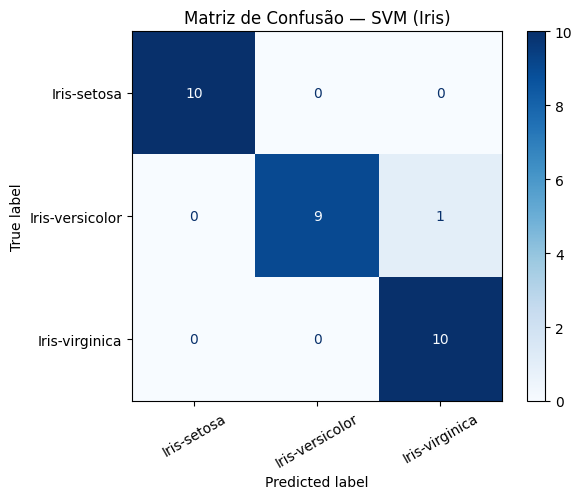

In [18]:
matriz_confusao = confusion_matrix(y_test, y_pred, labels=modelo_svm.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=modelo_svm.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão — SVM (Iris)")
plt.xticks(rotation=30)
plt.show()


Nessa matriz, cada linha é a espécie real e cada coluna é a espécie que o modelo previu. Os números na diagonal são os acertos; qualquer número fora da diagonal mostra uma confusão entre duas espécies. Usei essa visualização para deixar bem claro, visualmente, onde exatamente o modelo errou (quando errou).

### 9.4 Validação Cruzada

Até aqui eu tinha avaliado o modelo usando só uma divisão de treino/teste, mas sei que esse resultado pode variar dependendo de quais amostras caem em cada lado dessa divisão. Para ter mais confiança de que o resultado não foi só "sorte", fiz uma validação cruzada: dividi os dados em 5 partes (`cv=5`), treinei em 4 e testei na parte restante, repetindo esse processo 5 vezes com uma parte diferente de teste a cada rodada, e depois tirei a média das 5 acurácias obtidas.

In [19]:
X_norm_completo = StandardScaler().fit_transform(X)

modelo_cv = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

scores_cv = cross_val_score(modelo_cv, X_norm_completo, y, cv=5)

print("Acurácia em cada um dos 5 folds:", np.round(scores_cv, 4))
print(f"Acurácia média (validação cruzada): {scores_cv.mean():.4f} (+/- {scores_cv.std():.4f})")


Acurácia em cada um dos 5 folds: [0.9667 0.9667 0.9667 0.9333 1.    ]
Acurácia média (validação cruzada): 0.9667 (+/- 0.0211)


Como a acurácia média da validação cruzada ficou próxima da acurácia que obtive no passo 9.1, considero que o resultado do meu modelo é estável, e não só um acaso da divisão treino/teste que escolhi.

## 10. Visualization (Visualização Final)

Para fechar minha apresentação, retomei o pairplot que já tinha usado na EDA (passo 3.6), mas agora já sabendo como o modelo se saiu. Ele me ajuda a mostrar visualmente por que o SVM teve um bom desempenho: as espécies ocupam regiões relativamente bem definidas no espaço das 4 medidas, com uma sobreposição pequena e localizada só entre duas das três espécies.

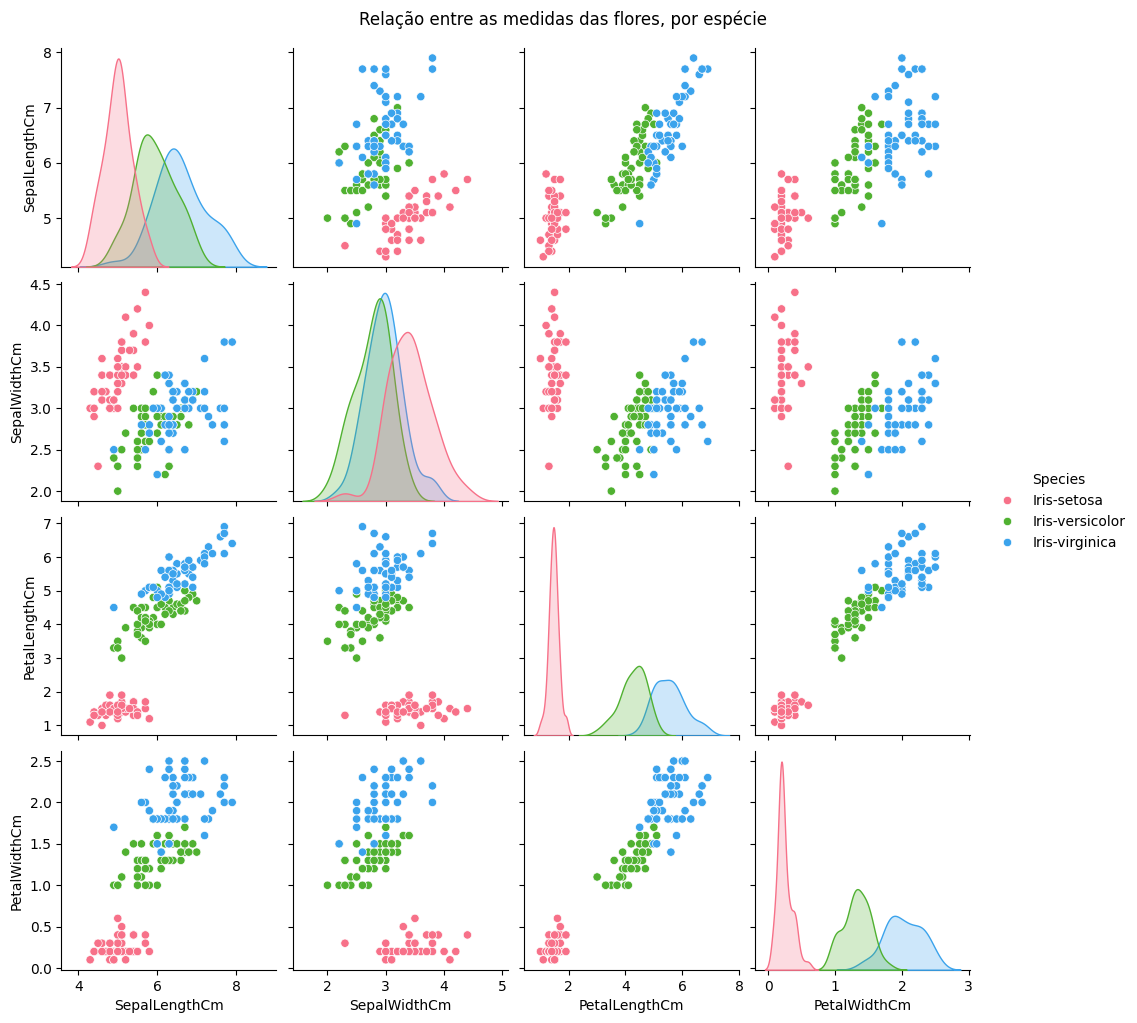

In [20]:
sns.pairplot(df, hue="Species", palette="husl")
plt.suptitle("Relação entre as medidas das flores, por espécie", y=1.02)
plt.show()


## Conclusão

Para resumir o que eu fiz nesta atividade:

1. **Setup** — importei as bibliotecas necessárias.
2. **Load Dataset** — carreguei o `Iris.csv` diretamente do dataset anexado no Kaggle, sem usar `load_iris()`.
3. **Initial Inspection (EDA)** — analisei estrutura, estatísticas, qualidade dos dados, balanceamento de classes, distribuições, correlações e relações entre variáveis, e usei essas observações para formar expectativas sobre o desempenho do modelo.
4. **Data Preparation** — removi a coluna `Id` e separei features (`X`) de target (`y`).
5. **Train/Test Split** — dividi os dados de forma estratificada, com reprodutibilidade garantida pelo `random_state`.
6. **Normalization** — padronizei as medidas com `StandardScaler`, tomando cuidado para não deixar informação do teste vazar para o treino.
7. **Train SVM Model** — treinei um `SVC` com kernel RBF, escolhido com base no que eu tinha visto na EDA, e expliquei o papel de `C` e `gamma`.
8. **Prediction** — gerei as previsões do modelo para o conjunto de teste.
9. **Evaluation** — avaliei com acurácia, classification report, matriz de confusão e validação cruzada, sempre relacionando os resultados de volta com o que eu já tinha observado na EDA.
10. **Visualization** — fechei retomando o pairplot, já com o contexto do desempenho do modelo.

De forma geral, o SVM com kernel RBF se saiu muito bem no dataset Iris, confirmando o que eu já esperava desde a análise exploratória: as classes são majoritariamente bem separáveis no espaço das 4 medidas, com eventuais confusões concentradas apenas entre *Iris-versicolor* e *Iris-virginica*, as duas espécies mais parecidas entre si.